In [2]:
# %matplotlib inline은 matpoltlib 그래프를 노트북 셀 안에 바로 그려주는 설정입니다.
%matplotlib inline

# pandas : 데이터 표(엑셀과 비슷한 형태) 로 다루는 라이브러리 입니다.
import pandas as pd

# numpy: 숫자 계산과 배열 연산을 위한 라이브러리 입니다. 거리 계산등에 사용합니다.
import numpy as np

# matplotlib: 그래프를 그리는 기본 시각화 도구 입니다.
import matplotlib.pyplot as plt

# seaborn: heatmap, barplot 처럼 보기 좋은 그래프를 그릴 때 사용합니다.
import seaborn as sns

# folium: 위도 / 경도 데이터를 지도 위에 표시 할 때 사용합니다.
import folium

# HeatMap: folium 지도 위에 데이터 밀집 정도를 색으로 표현하는 도구 입니다.
from folium.plugins import HeatMap

In [3]:
plt.style.use("ggplot")

In [4]:
# 한글 폰트 설정 (windows 기준). 폰트가 없거나 다른 OS 에서 실행해도 오류가 나지 않도록 예외 처리합니다.
try:
    plt.rcParams["font.family"] = "Malgun Gothic"
    plt.rcParams["axes.unicode_minus"] = False  # 마이너스 부호가 깨지지 않도록 설정합니다.
except Exception as e:
    print("한글 폰트 설정을 건너뜁니다.", e)

In [5]:
# read_csv: CSV 파일을 읽어 표 형태의 데이터 프레임 으로 만들어 주는 함수입니다.
# 같은 폴더에 jeju_bus.csv 파일이 있다고 가정합니다.
df = pd.read_csv("jeju_bus.csv")

# 데이터프레임 변수명을 마지막 줄에 두면 내용 일부가 표 형태로 표시 됩니다.
df

,id,date,route_id,vh_id,route_nm,now_latitude,now_longitude,now_station,now_arrive_time,distance,next_station,next_latitude,next_longitude,next_arrive_time
0,0,2019-10-15,405136001,7997025,360-1,33.456267,126.551750,제주대학교입구,06시,266,제대마을,33.457724,126.554014,24
1,1,2019-10-15,405136001,7997025,360-1,33.457724,126.554014,제대마을,06시,333,제대아파트,33.458783,126.557353,36
2,2,2019-10-15,405136001,7997025,360-1,33.458783,126.557353,제대아파트,06시,415,제주대학교,33.459893,126.561624,40
3,3,2019-10-15,405136001,7997025,360-1,33.479705,126.543811,남국원(아라방면),06시,578,제주여자중고등학교(아라방면),33.484860,126.542928,42
4,4,2019-10-15,405136001,7997025,360-1,33.485662,126.494923,도호동,07시,374,은남동,33.485822,126.490897,64
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210452,210452,2019-10-28,405328102,7983486,281-2,33.255783,126.577450,비석거리,21시,528,삼아아파트,33.251896,126.574417,96
210453,210453,2019-10-28,405328102,7983486,281-2,33.248595,126.568527,동문로터리,21시,280,매일올레시장 7번입구,33.249753,126.565959,50
210454,210454,2019-10-28,405328102,7983486,281-2,33.251891,126.560303,서귀포시 구 버스터미널,21시,114,아랑조을거리 입구,33.251084,126.559551,16
210455,210455,2019-10-28,405328102,7983486,281-2,33.251084,126.559551,아랑조을거리 입구,21시,223,평생학습관,33.249504,126.558068,38


In [6]:
# head(): 데이터의 앞부분 5개 행을 보여줍니다.
# 왜 하는가: 본격적인 분석 전에 실제 데이터 모양(컬럼 구성과 값 형태) 을 직접 눈으로 확인하기 위해서 입니다.
# 이 과정을 생략하면 데이터 구조를 모른 채 전처리 / 모델링을 진행하게 되어, 잘못된 컬럼을 쓰는 실수를 하게 됩니다.
df.head()

,id,date,route_id,vh_id,route_nm,now_latitude,now_longitude,now_station,now_arrive_time,distance,next_station,next_latitude,next_longitude,next_arrive_time
0,0,2019-10-15,405136001,7997025,360-1,33.456267,126.551750,제주대학교입구,06시,266,제대마을,33.457724,126.554014,24
1,1,2019-10-15,405136001,7997025,360-1,33.457724,126.554014,제대마을,06시,333,제대아파트,33.458783,126.557353,36
2,2,2019-10-15,405136001,7997025,360-1,33.458783,126.557353,제대아파트,06시,415,제주대학교,33.459893,126.561624,40
3,3,2019-10-15,405136001,7997025,360-1,33.479705,126.543811,남국원(아라방면),06시,578,제주여자중고등학교(아라방면),33.484860,126.542928,42
4,4,2019-10-15,405136001,7997025,360-1,33.485662,126.494923,도호동,07시,374,은남동,33.485822,126.490897,64


In [7]:
# shape: (행 개수, 열 개수) 형태로 데이터의 크기를 알려줍니다.
# 왜 하는가: 데이터가 몇 건인지 알아야 이후 산점도 샘플링이 필요한지, 그룹별 집계가 신뢰할 만한지 판단할 수 있습니다.
df.shape

(210457, 14)

In [8]:
# info(): 컬럼별 데이터 타입과 비어있지 않은 값(non_null) 개수를 보여줍니다.
# 왜 하는가: 숫자처럼 보이지만 문자로 저장된 컬럼(now_arrive_time 등) 이나 결측치를 미리 찾아내기 위해서 입니다.
# 이 결과를 보고 "어떤 컬럼을 숫자/날짜 로 바꿔야 하는지" 를 판단해 전처리 게획을 세웁니다.
df.info

<bound method DataFrame.info of             id        date   route_id    vh_id route_nm  now_latitude  \
0            0  2019-10-15  405136001  7997025    360-1     33.456267   
1            1  2019-10-15  405136001  7997025    360-1     33.457724   
2            2  2019-10-15  405136001  7997025    360-1     33.458783   
3            3  2019-10-15  405136001  7997025    360-1     33.479705   
4            4  2019-10-15  405136001  7997025    360-1     33.485662   
...        ...         ...        ...      ...      ...           ...   
210452  210452  2019-10-28  405328102  7983486    281-2     33.255783   
210453  210453  2019-10-28  405328102  7983486    281-2     33.248595   
210454  210454  2019-10-28  405328102  7983486    281-2     33.251891   
210455  210455  2019-10-28  405328102  7983486    281-2     33.251084   
210456  210456  2019-10-28  405328102  7983486    281-2     33.248487   

        now_longitude   now_station now_arrive_time  distance  \
0          126.551750     

In [9]:
# describe(): 숫자형 컬럼에 대해 개수, 평균, 표준편차, 최소/최대, 분위수를 요약 합니다.
# 왜 하는가: 각 숫자 컬럼의 값 범위와 치우침을 한 번에 파악하기 위해서 입니다.
# 평균과 최대값 차이가 매우 크면 이상치가 있다는 신호이므로, 뒤의 분포/이상치 확인으로 이어집니다.
df.describe()

,id,route_id,vh_id,now_latitude,now_longitude,distance,next_latitude,next_longitude,next_arrive_time
count,210457.000000,2.104570e+05,2.104570e+05,210457.000000,210457.000000,210457.000000,210457.000000,210457.000000,210457.000000
mean,105228.000000,4.052491e+08,7.988694e+06,33.434528,126.603451,490.256100,33.434711,126.603687,85.380824
std,60753.847139,9.132404e+04,6.774077e+03,0.102350,0.123961,520.563932,0.102224,0.123838,85.051170
min,0.000000,4.051360e+08,7.983000e+06,33.244382,126.473300,97.000000,33.244382,126.473300,6.000000
25%,52614.000000,4.051365e+08,7.983093e+06,33.325283,126.523900,291.000000,33.325283,126.524550,44.000000
50%,105228.000000,4.053201e+08,7.983431e+06,33.484667,126.551050,384.000000,33.484860,126.551050,66.000000
75%,157842.000000,4.053201e+08,7.997041e+06,33.500197,126.650322,542.000000,33.500228,126.650322,102.000000
max,210456.000000,4.053281e+08,7.997124e+06,33.556167,126.935188,7461.000000,33.556167,126.935188,2996.000000


In [10]:
# 각 컬럼에 비어있는 값(NAN)이 몇 개, 그리고 어떤 비율로 있는지 확인합니다.
# 왜 하는가: 실제 데이터에서는 센서 오류, 수집 누락, 입력 실수 등으로 결측치가 생길 수 있습니다.
# 결측치가 있는 상태로 모델을 학습하면 오류가 발생하거나 잘못된 패턴을 학습할 수 있으므로,
# 모델링 전에 결측치 여부를 먼저 확인해야 합니다.
# 개수(sum)와 비율(mean) 을 함께 보는 이유: 개수가 같아도 전체 대비 비율이 다르면 대응 방법이 달라지기 때문입니다.
missing_count = df.isnull().sum()
missing_ratio = df.isnull().mean()


# 개수와 비율을 한 표로 모으면 컬럼별 결측 상황을 한눈에 비교할 수 있습니다.
missing_df = pd.DataFrame({
    "missing_count": missing_count,
    "missing_ratio": missing_ratio,
})
missing_df

,missing_count,missing_ratio
id,0,0.0
date,0,0.0
route_id,0,0.0
vh_id,0,0.0
route_nm,0,0.0
now_latitude,0,0.0
now_longitude,0,0.0
now_station,0,0.0
now_arrive_time,0,0.0
distance,0,0.0


In [11]:
# "06시", "08시" 처럼 문자열로 저장된 시간을 숫자로 바꿉니다.
# 왜 하는가: 모델을 "06시", "08시" 같은 문자열의 시간 순서를 직접 이해하기 어렵습니다.
# 숫자 6, 8로 변환하면 시간대 별 도착시간 차이를 분석하거나 모델 feature로 사용할 수 있습니다.
# regex = False: "시"를 정규식 패턴이 아니라 글자 그대로 찾아 바꾸겠다는 의도를 분명히 합니다.
# now_hour 는 이후 '시간대별 평균 도착 시간' 분석과 baseline feature 후보로 연결됩니다.
df["now_hour"] = df["now_arrive_time"].str.replace("시", "", regex = False).astype(int)

# 변환 전(now_arrive_time) 과 변환 후(now_hour)를 나란히 확인합니다.
df[["now_arrive_time", "now_hour"]].head()

,now_arrive_time,now_hour
0,06시,6
1,06시,6
2,06시,6
3,06시,6
4,07시,7


In [12]:
# 문자형으로 저장된 날짜를 날짜형(datetime)으로 변환합니다.
# 왜하는가: 날짜형으로 바꿔야 .dt 기능으로 연/월/일/요일 을 추출 할 수 있습니다.
# 문자열 상태로는 "요일" 이나 "월" 같은 정보를 계산할 수 없습니다.
df["date"] = pd.to_datetime(df["date"])


In [13]:
# 닐짜형으로 바꾼 뒤에는 .dt 를 통해 연/월/일/요일을 추출 할 수 있습니다.
# 왜 하는가: 날짜 자체(2019-10-15)보다 요일/월/일 같은 파생 변수가 이동 패턴을 더 잘 설명 할 수 있기 때문입니다.
df["year"] = df["date"].dt.year     #년
df["month"] = df["date"].dt.month   #월
df["day"] = df["date"].dt.day       #일
df["dayofweek"] = df["date"].dt.dayofweek #요일 (월요일 = 0 ... 일요일 = 6)
# 주의 : 이번 데이터는 2019년 10월 의 약 2주 기간이라 year, month는 모든 행이 같은 값입니다.
# 따라서 year, month는 baseline feature 로는 의미가 작고, day 와 dayofweek 가 날짜 기반 feature 후보가 됩니다.

In [14]:
# 파생 변수가 잘 만들어졌는지 확인합니다.
df[["date", "year", "month", "day", "dayofweek"]].head()

,date,year,month,day,dayofweek
0,2019-10-15,2019,10,15,1
1,2019-10-15,2019,10,15,1
2,2019-10-15,2019,10,15,1
3,2019-10-15,2019,10,15,1
4,2019-10-15,2019,10,15,1


In [15]:
# describe(): target(next_arrive_time)의 개수, 평균, 표준편차, 최소 / 최대, 분위수 를 확인 합니다.
# 왜 하는가 : 예측해야 하는 값이 어떤 범위에 어떻게 퍼져 있는지 먼저 알아야 모델링 방향을 정할 수 있습니다.
# 특히 평균(mean)과 중앙값(50%) 을 비교하면 분포가 한쪽으로 치우쳤는지 판단할 수 있습니다.
df["next_arrive_time"].describe()

count    210457.000000
mean         85.380824
std          85.051170
min           6.000000
25%          44.000000
50%          66.000000
75%         102.000000
max        2996.000000
Name: next_arrive_time, dtype: float64

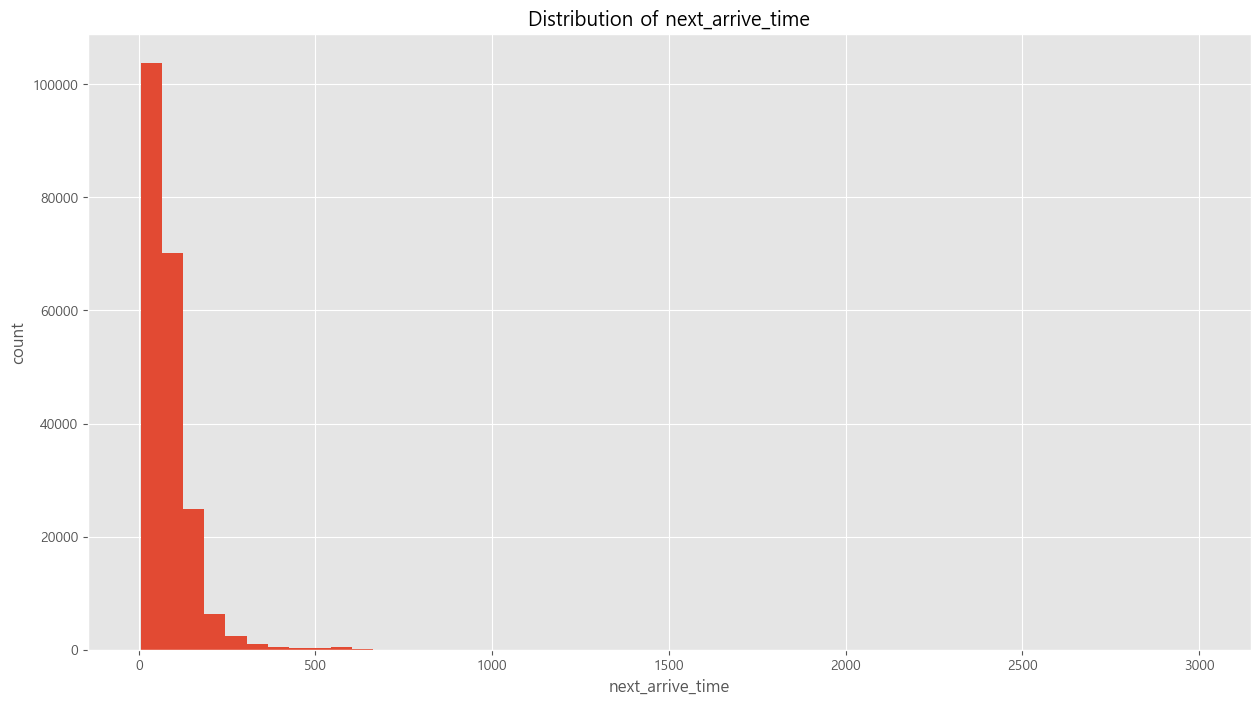

In [16]:
# 히스토그램: 값을 여러 구간(bin)으로 나누어 각 구간에 데이터가 몇개 있는지 막대로 보여줍니다.
# 왜 하는가: 도착 시간 값이 어디에 몰려있는지(분포 모양)를 눈으로 확인하기 위해서 입니다.
plt.figure(figsize = (15, 8))
plt.hist(df["next_arrive_time"], bins = 50)
plt.title("Distribution of next_arrive_time")
plt.xlabel("next_arrive_time")
plt.ylabel("count")
plt.show()

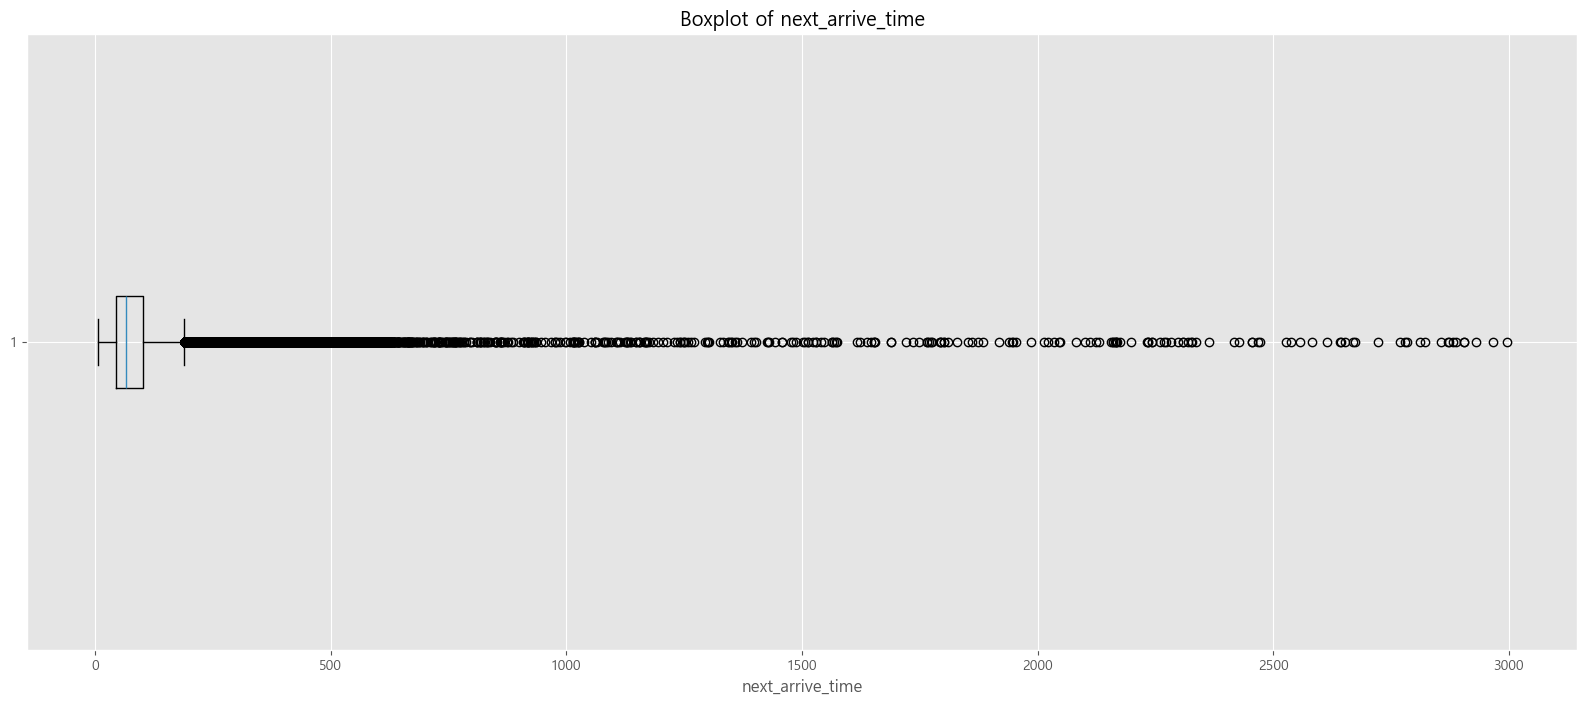

In [17]:
# 박스플롯: 데이터의 분포와 이상치(정상 범위를 벗어난 값)를 한눈에 보여줍니다.
# 왜 하는가: 히스토그램이 '어디에 몰려있는지' 를 본다면 , 박스플롯은 '얼마나 멀리 떨어진 값이 있는지' 를 빠르게 확인합니다.
# vert = False 는 박스플롯을 가로로 눕혀 그려, 긴 꼬리(큰 값)를 보기 편하게 합니다.
plt.figure(figsize = (20, 8))
plt.boxplot(df["next_arrive_time"], vert = False)
plt.title("Boxplot of next_arrive_time")
plt.xlabel("next_arrive_time")
plt.show()

In [18]:
# quantile: 데이터를 크기 순으로 줄 세웠을 때 특정 위치의 값을 알려줍니다.
# 왜 하는가: "상위 10%/5%/1% 는 어느정도 값 부터인가" 를 숫자로 확인해, 어디부터를 큰 값으로 볼지 기준을 잡기 위해서 입니다.
# 0.90 → 상위 10% 경계, 0.95 → 상위 5% 경계, 0.99 → 상위 1% 경계    
time_quantile = df["next_arrive_time"].quantile([0.90, 0.95, 0.99])
time_quantile

0.90    154.0
0.95    194.0
0.99    340.0
Name: next_arrive_time, dtype: float64

In [19]:
# 특정 기준값보다 큰 데이터가 몇 개인지 세어 봅니다.
# 왜 하는가: 큰 값이 '몇 건 정도'인지 알아야, 이상치가 드문 예외인지 무시 할 수 없는 규모인지 판단할 수 있습니다.
# (값 > 기준) 은 True / False 시리즈가 되고, sum() 은 True 의 개수를 세어줍니다.

over_300_count = (df["next_arrive_time"] > 300).sum()
over_600_count = (df["next_arrive_time"] > 600).sum()
over_1000_count = (df["next_arrive_time"] > 1000).sum()

print("300초과:", over_300_count)
print("600초과:", over_600_count)
print("1000초과:", over_1000_count)

300초과: 3070
600초과: 438
1000초과: 200


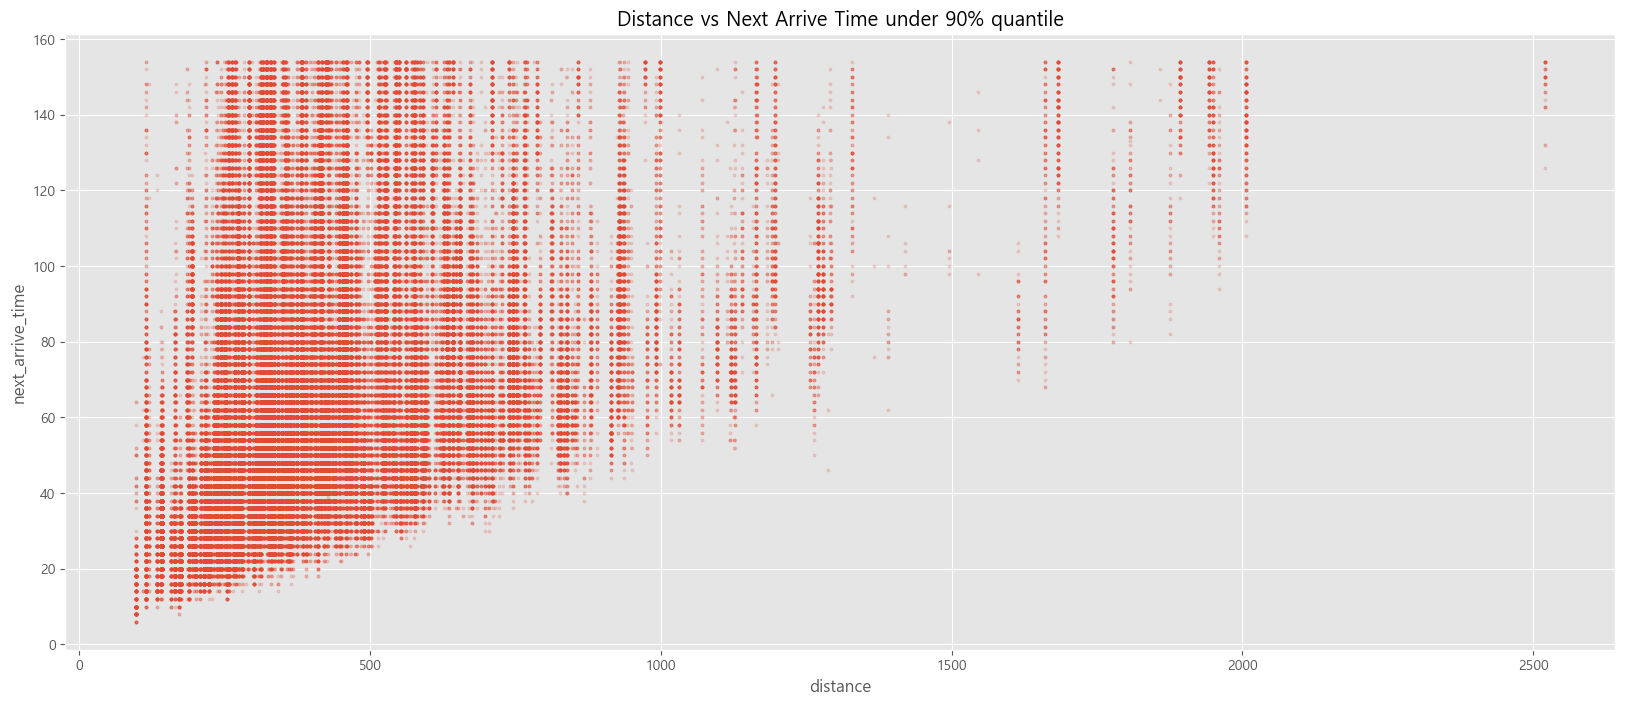

In [20]:
# 왜 q 90 이하만 따로 보는가:
# 상위 10% 처럼 매우 큰 값이 있으면, 그래프의 새로 축이 그 값까지 크게 늘어납니다.
# 축이 크게 늘어나면 대부분의 일반 데이터가 아래쪽에 눌려 보여 패턴을 확인하기 어렵습니다.
# 그래서 90% 분위수 이하 데이터만 따로 그려, 일반적인 구간의 관계를 더 또렷하게 봅니다.
# 주의: 이는 '시각화를 위해 잠깐 따로 보는 것' 이며, 상위 1% 데이터를 실제로 삭제한다는 뜻은 아닙니다.
q90 = df["next_arrive_time"].quantile(0.90)

df_under_q90 = df[df["next_arrive_time"] <= q90]

plt.figure(figsize = (20, 8))
plt.scatter(
    df_under_q90["distance"],
    df_under_q90["next_arrive_time"],
    alpha = 0.2,
    s = 5
)
plt.title("Distance vs Next Arrive Time under 90% quantile")
plt.xlabel("distance")
plt.ylabel("next_arrive_time")
plt.show()

In [21]:
# 상관관계를 볼 의미가 있는 숫자 컬럼만 직접 선택 합니다.
# 왜 id, route_id, vh_id 를 제외하는가:
#   이들은 숫자로 되어 있지만 실제 크기 비교에 의미가 있는값이 아닙니다.
#   예로 들어 route_id 가 크다고 해서 더 긴 노선이거나 더 중요한 노선이라는 뜻은 아닙니다.
#   따라서 수치적 의미가 있는 distance, next_arrive_time, now_hour 만 사용합니다.
corr_cols = [
    "distance",
    "next_arrive_time",
    "now_hour"
    
]

corr_data = df[corr_cols]
corr_matrix = corr_data.corr() # 컬럼들 사이의 상관계수를 사용합니다. (-1 ~ 1)
corr_matrix 

,distance,next_arrive_time,now_hour
distance,1.000000,0.437166,-0.004834
next_arrive_time,0.437166,1.000000,-0.001209
now_hour,-0.004834,-0.001209,1.000000


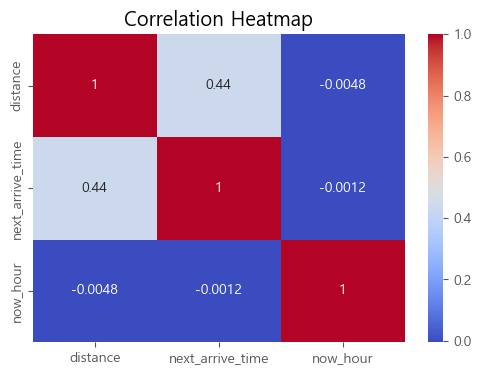

In [22]:
# heatmap: 상관계수를 색으로 표현합니다. 1에 가까우면 빨강, -1에 가까우면 파랑입니다.
# 주의: 상관관계는 두 변수 관계의 '강도' 를 보는 참고 자료일 뿐, 원인과 결과(인과관계)를  확정하는 도구는 아닙니다.
plt.figure(figsize =(6,4))
sns.heatmap(corr_matrix, annot = True, cmap = "coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [23]:
# now_hour 로 묶어서, 각 시간대에 데이터가 몇 개인지 셉니다. 
# 왜 개수를 먼저 보는가: 데이터가 적은 시간대 (예: 새벽)의 평균운 신뢰도가 낮으므로,
# 평균을 해석하기 전에 그룹별 데이터 개수를 먼저 확인합니다.
hour_count = df.groupby("now_hour")["next_arrive_time"].count()
hour_count

now_hour
0         5
5       487
6      8409
7     13581
8     13838
9     13700
10    13011
11    12524
12    13433
13    13197
14    12592
15    12846
16    13476
17    13090
18    12987
19    13275
20    11852
21    11230
22     6470
23      454
Name: next_arrive_time, dtype: int64

In [24]:
# 같은 방식으로, 시간대별 평균 도착 시간을 구합니다.
hour_mean_time = df.groupby("now_hour")["next_arrive_time"].mean()
hour_mean_time

now_hour
0      56.000000
5     132.956879
6      85.986443
7      85.488697
8      87.666715
9      82.414015
10     82.623780
11     83.547988
12     83.550733
13     84.070471
14     84.036134
15     84.904250
16     86.759573
17     90.705271
18     94.958882
19     87.240979
20     83.124705
21     82.479252
22     75.355796
23     63.387665
Name: next_arrive_time, dtype: float64

In [25]:
# 마지막으로 개수(count), 평균(mean), 중앙값(medium)을 한 표로 정리합니다.
hour_summary = df.groupby("now_hour")["next_arrive_time"].agg(
    ["count", "mean", "median"]
)
hour_summary

,count,mean,median
now_hour,,,
0,5,56.000000,36.0
5,487,132.956879,66.0
6,8409,85.986443,64.0
7,13581,85.488697,66.0
8,13838,87.666715,66.0
9,13700,82.414015,64.0
10,13011,82.623780,66.0
11,12524,83.547988,66.0
12,13433,83.550733,66.0


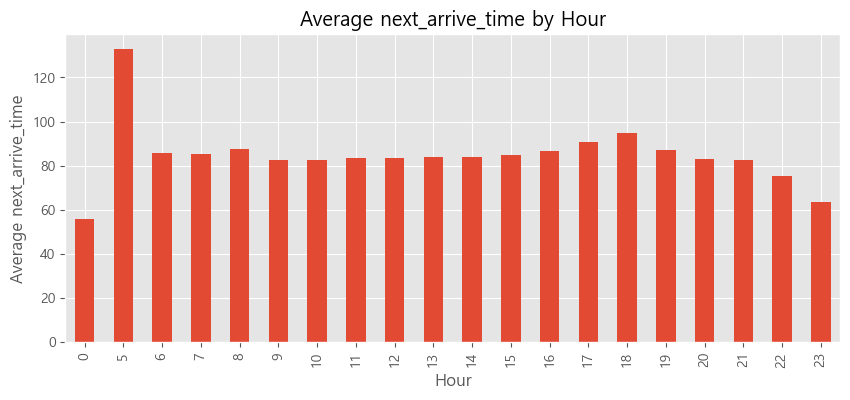

In [26]:
# 시간대별 평균 도착 시간을 막대 그래프로 그립니다.
hour_summary["mean"].plot(kind="bar", figsize =(10, 4))
plt.title("Average next_arrive_time by Hour")
plt.xlabel("Hour")
plt.ylabel("Average next_arrive_time")
plt.show()

In [27]:
# 요일별 데이터 개수
day_count = df.groupby("dayofweek")["next_arrive_time"].count()
day_count

dayofweek
0    30353
1    31311
2    30818
3    30968
4    30003
5    28806
6    28198
Name: next_arrive_time, dtype: int64

In [28]:
# 요일별 평균 도착 시간
day_mean_time = df.groupby("dayofweek")["next_arrive_time"].mean()
day_mean_time

dayofweek
0    85.926136
1    85.476095
2    86.133721
3    86.487632
4    86.913709
5    83.720544
6    82.714732
Name: next_arrive_time, dtype: float64

In [29]:
# 요일별 개수/평균/중앙값 정리
day_summary = df.groupby("dayofweek")["next_arrive_time"].agg(
    ["count","mean", "median"]    
)
day_summary

,count,mean,median
dayofweek,,,
0,30353,85.926136,66.0
1,31311,85.476095,66.0
2,30818,86.133721,66.0
3,30968,86.487632,66.0
4,30003,86.913709,66.0
5,28806,83.720544,64.0
6,28198,82.714732,64.0


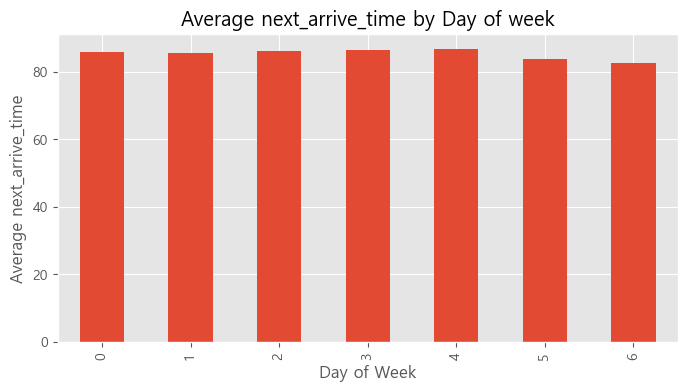

In [30]:
# 요일별 평균 도착 시간 막대그래프
day_summary["mean"].plot(kind="bar", figsize = (8,4))
plt.title("Average next_arrive_time by Day of week")
plt.xlabel("Day of Week")
plt.ylabel("Average next_arrive_time")
plt.show()

In [31]:
# 노선별 데이터 개수
route_count = df.groupby("route_nm")["next_arrive_time"].count()
route_count

route_nm
201-11     7895
201-12    11871
201-13     2631
201-14    12999
201-15     2289
201-16    15451
201-17     5102
201-18     2558
201-21     2670
201-22     7723
201-24     2368
201-26     2665
201-27     5950
281-1     19150
281-2     25884
360-1     21668
360-12     8037
360-2      7709
360-7      2070
365-21    11826
365-22    31941
Name: next_arrive_time, dtype: int64

In [32]:
# 노선별 평균 도착 시간
route_mean_time = df.groupby("route_nm")["next_arrive_time"].mean()
route_mean_time

route_nm
201-11     68.901710
201-12     67.602392
201-13     68.403649
201-14     66.634818
201-15     71.313237
201-16     68.122969
201-17     69.239122
201-18     67.643471
201-21     65.985019
201-22     63.955199
201-24     66.205659
201-26     66.512570
201-27     70.824370
281-1      87.579634
281-2      85.744862
360-1      92.063688
360-12    111.322633
360-2     108.270852
360-7      94.172947
365-21    114.673939
365-22    101.339188
Name: next_arrive_time, dtype: float64

In [33]:
# 노선별 개수/평균/중앙값 정리 후, 평균이 큰 노선 순으로 정렬
route_summary = df.groupby("route_nm")["next_arrive_time"].agg(
    ["count", "mean", "median"]
)
route_summary = route_summary.sort_values("mean", ascending = False)
route_summary

,count,mean,median
route_nm,,,
365-21,11826,114.673939,90.0
360-12,8037,111.322633,82.0
360-2,7709,108.270852,84.0
365-22,31941,101.339188,80.0
360-7,2070,94.172947,82.0
360-1,21668,92.063688,80.0
281-1,19150,87.579634,68.0
281-2,25884,85.744862,70.0
201-15,2289,71.313237,54.0


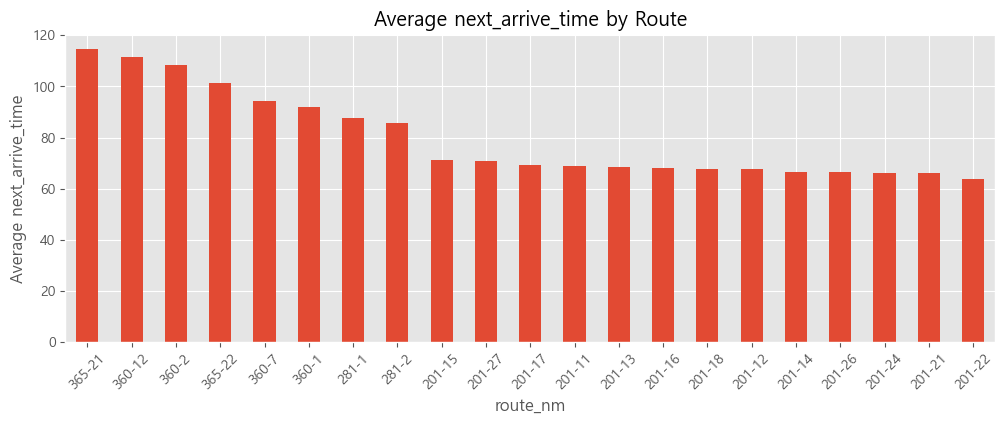

In [34]:
# 노선별 평균 도착 시간 막대그래프
route_summary["mean"].plot(kind="bar", figsize =(12,4))
plt.title("Average next_arrive_time by Route")
plt.xlabel("route_nm")
plt.ylabel("Average next_arrive_time")
plt.xticks(rotation = 45)
plt.show()

In [35]:
# "현재 정류장 → 다음 정류장" 형태의 구간 문자열을 만듭니다.
# 왜 하는가: 이동 시간은 정류장 하나보다 '어느 구간을 이동했는가' 의 영향을 더 직접적으로 받을수 있기 때문입니다.
# astype(str) 로 문자형으로 맞춘 뒤 문자열을 이어 붙입니다.
# 주의: station_segment 는 EDA 분석용 컬럼입니다. baseline 모델 feature 에는 자동 포함하지 않습니다.
#       고유값이 더 늘어날 수 있어, 개선  단계에서 성능을 별도로 비교한 뒤 추가여부를 정합니다.
df["station_segment"] = (
    df["now_station"].astype(str)
    + " → "
    + df["next_station"].astype(str)
)

In [36]:
# 구간이 잘 만들어 졌는지 확인합니다.
df[["now_station", "next_station", "station_segment"]].head()

,now_station,next_station,station_segment
0,제주대학교입구,제대마을,제주대학교입구 → 제대마을
1,제대마을,제대아파트,제대마을 → 제대아파트
2,제대아파트,제주대학교,제대아파트 → 제주대학교
3,남국원(아라방면),제주여자중고등학교(아라방면),남국원(아라방면) → 제주여자중고등학교(아라방면)
4,도호동,은남동,도호동 → 은남동


In [37]:
# 구간 별 데이터 개수 (운행이 많은 구간 상위 10개)
segment_count = df.groupby("station_segment")["next_arrive_time"].count()
segment_count.sort_values(ascending = False).head(10)

station_segment
은남동 → 도호동                             1933
남국원(아라방면) → 아라초등학교                    1915
아라초등학교 → 아라주공아파트                      1911
제원아파트 → 은남동                           1897
아라주공아파트 → 인다마을                        1849
제주여자중고등학교(아라방면) → 남국원(아라방면)           1794
인다마을 → 제주대학교병원                        1779
제주중앙여자고등학교(아라방면) → 제주여자중고등학교(아라방면)    1761
제주시청(아라방면) → 고산동산(아라방면)               1760
제주지방법원(아라방면) → 제주중앙여자고등학교(아라방면)       1741
Name: next_arrive_time, dtype: int64

In [38]:
# 구간별 평균 도착 시간 (평균이 긴 구간 상위 10개)
segment_mean_time = df.groupby("station_segment")["next_arrive_time"].mean()
segment_mean_time.sort_values(ascending=False).head(10)

station_segment
노형초등학교 → 정존마을              2182.800000
부영아파트 → 제주고등학교/중흥S클래스      2166.000000
서귀포여자고등학교 → 수모루            2160.000000
노형오거리 → 노형초등학교             1773.777778
사회복지법인 춘강 → 산천단 한국폴리텍대학    1478.000000
정존마을 → 제주한라대학교             1253.000000
한국병원 → 제주버스터미널(가상정류소)      1125.333333
제주고등학교/중흥S클래스 → 탐라도서관       634.500000
탐라도서관 → 제주고등학교/중흥S클래스       613.400000
성판악 → 수악교                   562.773234
Name: next_arrive_time, dtype: float64

In [39]:
# 구간별 개수/평균/중앙값 정리
segment_summary = df.groupby("station_segment")["next_arrive_time"].agg(
    ["count","mean","median"]
)

# 데이터가 너무 적은 구간은 평균이 불안정 하므로, 100건 이상인 구간만 남깁니다.
segment_summary = segment_summary[segment_summary["count"] >= 100]
segment_summary = segment_summary.sort_values("mean",ascending = False)
segment_summary.head(10)

,count,mean,median
station_segment,,,
탐라도서관 → 제주고등학교/중흥S클래스,380,613.400000,547.0
성판악 → 수악교,269,562.773234,560.0
수악교 → 성판악,319,551.072100,548.0
시티주유소 → 제주한라대학교(종점),227,423.162996,68.0
제주도청 신제주로터리 → 제주국제공항(구제주방면),815,360.272393,338.0
고성리제주은행 → 성산환승정류장(고성리 회전교차로),332,327.722892,337.0
성판악 → 교래입구,421,314.931116,308.0
고성리 구 성산농협 → 성산환승정류장(고성리 한국물류),170,302.235294,336.0
교래입구 → 성판악,387,301.922481,296.0


In [40]:
# 제주도 내 주용 기준 지점 (위도, 경도)
# up : 제주공항 주변
# right: 제주 동쪽 성산일출봉 . 종달리 방면
# center: 한라산 / 중산간 지역 (밀집 지역이라기 보다 제주 중앙부 기준점)
# down : 서귀포 근처
up = (33.506286, 126.490312)            # 제주공항
right = (33.493521, 126.895326)         # 성산일출봉 방면
center = (33.506286, 126.545315)        # 한라산 / 중산간
down = (33.246742, 126.562387)            # 서귀포시 근처

In [41]:
# 지도 생성: 제주도 중심 좌표의 확대 수준(zoom_start)을 지정합니다.
jeju_map = folium.Map(
    location = [33.38, 126.55],
    zoom_start = 10
)

# 예시: 원본 데이터가 df라고 가정할 때, 정류장 위치 정보만 추출하여 생성
# 데이터 컬럼명은 실제 데이터셋에 맞춰 수정해야 합니다.
station_location_df = df[['now_station', 'now_latitude', 'now_longitude']].drop_duplicates()

# 중복 제거된 정류장 위치마다 작은 원을 찍습니다.
for _, row in station_location_df.iterrows():
    folium.CircleMarker(
       location = [row["now_latitude"], row["now_longitude"]],
       radius = 2, 
       fill = True,
       fill_opacity = 0.5,
       popup = row["now_station"]  
    ).add_to(jeju_map)
    
# 기준점 세 곳에 기본 아이콘 마커를 추가 합니다.(실행 안정성을 위해 기본 아이콘 사용)
folium.Marker(
    location = [up[0], up[1]],
    popup = "제주공항",
    tooltip = "제주공항",
    icon = folium.Icon(color = "blue")
).add_to(jeju_map)

folium.Marker(
    location = [right[0], right[1]],
    popup = "성산일출봉 방면",
    tooltip = "성산일출봉 방면",
    icon = folium.Icon(color = "green")
).add_to(jeju_map)

folium.Marker(
    location = [center[0], center[1]],
    popup = "한라산 / 중산간",
    tooltip = "한라산 / 중산간",
    icon = folium.Icon(color = "red")
).add_to(jeju_map)

folium.Marker(
    location = [down[0], down[1]],
    popup = "서귀포 방면",
    tooltip = "서귀포 방면",
    icon = folium.Icon(color = "purple")
).add_to(jeju_map)

#필요하면 아래 코드로 지도를 HTML 파일로 저장 할 수 있습니다.
# jeju_map.save("jeju_bus_stop_map.html")

#셀 마지막 줄에 지도 객체를 두면 노트북에 지도가 바로 표시됩니다.
jeju_map

In [44]:
# HeatMap용 지도 생성
jeju_heatmap = folium.Map(
    location = [33.38, 126.55],
    zoom_start = 10
)

# HeatMap 은 [위도, 경도] 목록을 입력으로 받습니다.
heat_data = station_location_df[["now_latitude","now_longitude"]].values.tolist()

HeatMap(
    heat_data,
    radius = 15,
    blur = 20 
).add_to(jeju_heatmap)

# 기준점 마커 추가
folium.Marker(
    location = [up[0], up[1]],
    popup = "제주공항",
    tooltip = "제주공항",
    icon = folium.Icon(color = "blue")
).add_to(jeju_heatmap)

folium.Marker(
    location = [right[0], right[1]],
    popup = "성산일출봉 방면",
    tooltip = "성산일출봉 방면",
    icon = folium.Icon(color = "green")
).add_to(jeju_heatmap)

folium.Marker(
    location = [center[0], center[1]],
    popup = "한라산 / 중산간",
    tooltip = "한라산 / 중산간",
    icon = folium.Icon(color = "red")
).add_to(jeju_heatmap)

folium.Marker(
    location = [down[0], down[1]],
    popup = "서귀포 방면",
    tooltip = "서귀포 방면",
    icon = folium.Icon(color = "red")
).add_to(jeju_heatmap)

# 필요하면 아래 코드로 지도를 HTML 파일로 저장할 수 있습니다.
# jeju_heatmap.save("jeju_bus_stop_heatmap.html")

jeju_heatmap